In [142]:
# Importing function to load datasets

import sys
sys.path.append("../src")

from data_loader_rachel import load_data

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
df_demo, df_web, df_experiment = load_data("../data/raw/")

Datasets loaded successfully:
Demo: (70609, 9)
Web: (755405, 5)
Experiment: (70609, 2)


In [145]:
# Double checking

df_demo.head()
df_web.head()
df_experiment.head()

df_demo.shape, df_web.shape, df_experiment.shape

((70609, 9), (755405, 5), (70609, 2))

### Quick reminder

df_demo → Who the client is

df_experiment → Which group they are in (control/test)

df_web → What they actually did

This means:
- Multiple rows per client
- Each row = a user interaction / step / event
- This is our behavioral dataset (very valuable for analysis)

# Analyzing contents of datasets and potential improvements

In [146]:
# Checking out columns and common keys

df_demo.columns
df_experiment.columns
df_web.columns

Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time'], dtype='str')

In [147]:
# Looking at the first few rows

df_demo.head()
df_experiment.head()
df_web.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [148]:
# Understanding the structure: client_id is the common denominator in all datasets! Non-null values anywhere!

df_demo.info()
df_experiment.info()
df_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB
<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  70609 non-null  int64
 1   variation  50500 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeI

### Fixes: date_time was set as str 

This is critical because later we'll need:
- session ordering
- time differences
- funnel analysis

In [149]:
df_web['date_time'] = pd.to_datetime(df_web['date_time'])
df_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 755405 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     755405 non-null  int64         
 1   visitor_id    755405 non-null  str           
 2   visit_id      755405 non-null  str           
 3   process_step  755405 non-null  str           
 4   date_time     755405 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 28.8 MB


### Fixes: Missing values in df_demo

In [150]:
df_demo = df_demo.dropna()
df_demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


### Fixes: Missing variation in df_experiment

70609 (rows) - 50500 (non-null values in column) = 20109 missing values (where variation is missing)

- Variation tells us whether a client is in a control group or in a test group!
- So if variation is missing, that client was NOT part of the experiment.

**To be aware: There are 14 missing values in df_demo - pretty clean already**

In [151]:
df_experiment = df_experiment.dropna(subset=['variation'])
df_experiment

,client_id,variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
50495,393005,Control
50496,2908510,Control
50497,7230446,Test
50498,5230357,Test


### Keep only the last funnel attempt per client

"If a customer has several start times, only the last one must be considered"

- find the last start event for each client_id
- keep only the rows from that attempt onward
- discard earlier attempts
- at the end, use visit_id to keep the visit containing the last start for each client.

In [152]:
# Set it to date_time
df_web['date_time'] = pd.to_datetime(df_web['date_time'])

In [153]:
# Inspecting names just to be sure
df_web['process_step'].value_counts()

process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64

In [154]:
# Keep only start rows
starts = df_web[df_web['process_step'] == 'start'].copy()

# For each client, find the latest start time
last_starts = starts.groupby('client_id', as_index=False)['date_time'].max()
last_starts = last_starts.rename(columns={'date_time': 'last_start_time'})

last_starts.head()

,client_id,last_start_time
0,169,2017-04-12 20:19:36
1,336,2017-06-01 07:42:43
2,546,2017-06-17 10:03:29
3,555,2017-04-15 12:57:56
4,647,2017-04-12 15:41:28


In [155]:
# Identify which visit that last start belongs to
last_start_visits = (
    df_web[df_web['process_step'] == 'start']
    .merge(last_starts, on='client_id', how='inner')
)

last_start_visits = last_start_visits[
    last_start_visits['date_time'] == last_start_visits['last_start_time']
][['client_id', 'visit_id', 'last_start_time']].drop_duplicates()

last_start_visits.head()

,client_id,visit_id,last_start_time
0,9988021,781255054_21935453173_531117,2017-04-17 15:16:22
1,8320017,960651974_70596002104_312201,2017-04-05 13:08:06
2,4033851,949661017_22392791362_127391,2017-04-05 12:24:04
3,1982004,132494692_73738638511_70823,2017-04-17 11:59:42
4,9294070,116640698_27328181095_188045,2017-04-17 11:16:28


In [156]:
df_web_last_attempt = df_web.merge(
    last_start_visits,
    on=['client_id', 'visit_id'],
    how='inner'
)

# Keep only rows from the last start onward
df_web_last_attempt = df_web_last_attempt[
    df_web_last_attempt['date_time'] >= df_web_last_attempt['last_start_time']
].copy()

# Sort nicely
df_web_last_attempt = df_web_last_attempt.sort_values(
    ['client_id', 'visit_id', 'date_time']
)

# FINAL RESULT OF THE TASK
df_web_last_attempt.head(10)

,client_id,visitor_id,visit_id,process_step,date_time,last_start_time
221873,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,2017-04-12 20:19:36
221872,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,2017-04-12 20:19:36
221871,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,2017-04-12 20:19:36
221870,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,2017-04-12 20:19:36
221869,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09,2017-04-12 20:19:36
514805,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:42:43,2017-06-01 07:42:43
353028,546,475037402_89828530214,731811517_9330176838_94847,start,2017-06-17 10:03:29,2017-06-17 10:03:29
353027,546,475037402_89828530214,731811517_9330176838_94847,step_1,2017-06-17 10:03:39,2017-06-17 10:03:29
353026,546,475037402_89828530214,731811517_9330176838_94847,step_2,2017-06-17 10:03:52,2017-06-17 10:03:29
353025,546,475037402_89828530214,731811517_9330176838_94847,step_3,2017-06-17 10:05:19,2017-06-17 10:03:29


In [157]:
# Validation: seeing clients with multiple start times, to make sure the logic is right - and it is!

df_web.groupby('client_id')['visit_id'].nunique().sort_values(ascending=False).head()

client_id
2128341    21
9852814    18
7787381    17
4925232    17
244312     17
Name: visit_id, dtype: int64

In [158]:
multi_start_clients = (
    df_web[df_web['process_step'] == 'start']
    .groupby('client_id')
    .size()
    .loc[lambda x: x > 1]
)

example_client = multi_start_clients.index[0]

df_web[df_web['client_id'] == example_client].sort_values('date_time')

,client_id,visitor_id,visit_id,process_step,date_time
628456,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:26:55
628331,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:42:43


# Isolate data per FIRST Start time and LAST Confirm time, grouping it by visit_id

df_visit_window will contain only the part of each visit that belongs to the funnel window:
- starting at that visit’s first start
- ending at that visit’s last confirm

So if a visit has noise before the process starts, or repeated events after confirmation, those rows are excluded.

In [159]:
# First start
first_start = (
    df_web[df_web['process_step'] == 'start']
    .groupby('visit_id', as_index=False)['date_time']
    .min()
    .rename(columns={'date_time': 'first_start_time'})
)

# Last confirm
last_confirm = (
    df_web[df_web['process_step'] == 'confirm']
    .groupby('visit_id', as_index=False)['date_time']
    .max()
    .rename(columns={'date_time': 'last_confirm_time'})
)

# Keep only visits that have both a start and a confirm
visit_limits = first_start.merge(last_confirm, on='visit_id', how='inner')

# Attach those limits back to the original data
df_visit_window = df_web.merge(visit_limits, on='visit_id', how='inner')

# Keep only rows between first start and last confirm
df_visit_window = df_visit_window[
    (df_visit_window['date_time'] >= df_visit_window['first_start_time']) &
    (df_visit_window['date_time'] <= df_visit_window['last_confirm_time'])
].copy()

# Sort neatly
df_visit_window = df_visit_window.sort_values(['visit_id', 'date_time'])
df_visit_window = df_visit_window.reset_index(drop=True)

df_visit_window.head(20)

,client_id,visitor_id,visit_id,process_step,date_time,first_start_time,last_confirm_time
0,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,2017-06-04 01:07:29,2017-06-04 01:09:50
1,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,2017-06-04 01:07:29,2017-06-04 01:09:50
2,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,2017-06-04 01:07:29,2017-06-04 01:09:50
3,9056452,306992881_89423906595,1000165_4190026492_760066,step_3,2017-06-04 01:09:13,2017-06-04 01:07:29,2017-06-04 01:09:50
4,9056452,306992881_89423906595,1000165_4190026492_760066,confirm,2017-06-04 01:09:50,2017-06-04 01:07:29,2017-06-04 01:09:50
5,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,2017-04-09 16:20:56,2017-04-09 16:24:58
6,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,2017-04-09 16:20:56,2017-04-09 16:24:58
7,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,2017-04-09 16:20:56,2017-04-09 16:24:58
8,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:35,2017-04-09 16:20:56,2017-04-09 16:24:58
9,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:41,2017-04-09 16:20:56,2017-04-09 16:24:58


In [160]:
# TO EXPORT without clutter columns later, if needed:
# df_export = df_visit_window.drop(columns=['first_start_time', 'last_confirm_time'])

In [161]:
df_visit_window.to_csv("../data/clean/df_visit_window.csv", index=False)

### **Slide-ready explainer:**

This is a modeling decision about how to represent user behavior.

We define each visit as a single funnel attempt, bounded by:
- the first Start → when the user initiates the process
- the last Confirm → when the process is successfully completed
- This ensures we capture the full journey from entry to completion.

### Why FIRST Start?
The first start represents:
- the true entry point into the process
- the moment the user intentionally begins the task

If we used a later start instead:
- we would be ignoring earlier failed or abandoned attempts within the same visit
- we would be underestimating friction and user effort
- so the first start preserves the complete initial intent and effort

### Why LAST Confirm?
The last confirmation represents:
- the final successful completion of the process
- even if the user: retries, makes mistakes, loops back through steps

If we used the first confirm instead:
- we might miss retries or corrections
- we would underestimate how long or complex completion actually was
- so the last confirm captures the true end of the successful journey

### Why this matters for a funnel analysis
Our process is not linear—it allows: backtracking, repeated steps, multiple attempts within the same visit
It sees all friction, retries, and delays are included.
Each visit is treated as one complete attempt.

### This approach answers

“How does a user actually experience the process from beginning to successful completion?”
Rather than:
“What is the shortest possible path through the process?”

### In A/B Testing our goal is to compare control vs test experience
If we didn’t standardize the funnel boundaries:
- we would compare inconsistent journeys
- results would be biased or misleading
- now we have a fair comparison

# KPI for Task Completion Time

Time between first Start and last Confirm (per visit)

So for each visit_id:
completion time = last_confirm_time − first_start_time

In [162]:
df_visit_window['task_time_seconds'] = (
    df_visit_window['last_confirm_time'] - df_visit_window['first_start_time']
).dt.total_seconds()

In [163]:
# Reduce to ONE row per visit, with the task time in seconds
df_visit_time = (
    df_visit_window.groupby('visit_id')
    .agg(
        client_id=('client_id', 'first'),
        task_time_seconds=('task_time_seconds', 'first')
    )
    .reset_index()
)

In [164]:
# Convert to more readable format (minutes)
df_visit_time['task_time_minutes'] = df_visit_time['task_time_seconds'] / 60

In [165]:
# Calculate the KPI: average time to complete the task (from first start to last confirm)
mean_time = df_visit_time['task_time_minutes'].mean()
median_time = df_visit_time['task_time_minutes'].median()

mean_time, median_time

(np.float64(7.088332880358584), np.float64(4.366666666666666))

In [166]:
# Split by control vs test groups
df_visit_time = df_visit_time.merge(
    df_experiment[['client_id', 'variation']],
    on='client_id',
    how='inner'
)

In [167]:
# Result
df_visit_time.groupby('variation')['task_time_minutes'].agg(['mean', 'median', 'count'])

,mean,median,count
variation,,,
Control,6.814131,4.65,14756
Test,7.053696,4.25,17771


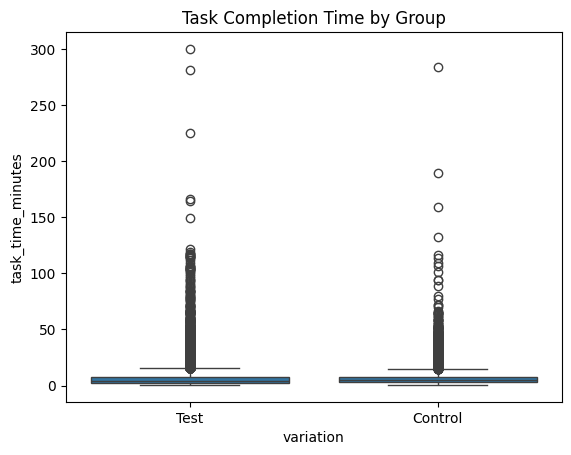

In [168]:
sns.boxplot(data=df_visit_time, x='variation', y='task_time_minutes')
plt.title("Task Completion Time by Group")
plt.show()

### **Slide-ready explainer:**

Task Completion Time
- Defined as time between first “Start” and last “Confirm” per visit
- Measures efficiency of the user journey

KPI Calculation
- Average time per visit
- Compared across Control vs Test groups

Interpretation
- Lower time → smoother, more efficient experience
- Higher time → potential friction or complexity

----

- mean → average completion time (minutes)
- median → middle value (robust to outliers)
- count → number of visits

----


1. The TEST group takes slightly longer on average (~7.05 min vs ~6.81 min)

**At first glance the new UI did not reduce completion time**

2. BUT the Median tells a different story, being lower in TEST (4.25 min vs 4.65 min)

**This suggests that typical users are actually faster in the Test group**

3. Why mean and median disagree (this is key insight)

**The Test group has more extreme long-duration cases (outliers)**

In other words:
- Most users are faster
- But some users take much longer, pulling the average up

While the average completion time is slightly higher in the Test group (NEW UI DESIGN), the median time is lower. This indicates that most users complete the process faster with the new interface, but a subset of users experience significantly longer completion times, increasing the overall average.

4. What this means behaviorally

**The new UI might be more efficient for most users, but confusing or problematic for a subset**

5. Sample size (important for credibility)

**Control: ~14.7k visits / Test: ~17.7k visits**


In [169]:
# Determine how many of the sample size were individual clients

df_visit_time.groupby('variation')['client_id'].nunique()

df_visit_time.groupby('variation').agg(
    visits=('visit_id', 'count'),
    unique_clients=('client_id', 'nunique')
)

,visits,unique_clients
variation,,
Control,14756,14727
Test,17771,17720


# KPI for Task Completion Time Per Step

In [170]:
df_visit_window = df_visit_window.sort_values(
    ['visit_id', 'date_time']
)

In [171]:
# Find time between steps
df_visit_window['step_time_seconds'] = (
    df_visit_window.groupby('visit_id')['date_time']
    .diff()
    .dt.total_seconds()
)

In [172]:
# Remove first rows, which have no previous step to compare to
df_steps = df_visit_window.dropna(subset=['step_time_seconds'])

In [173]:
# Merge variation into step dataset
df_steps.columns

Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time',
       'first_start_time', 'last_confirm_time', 'task_time_seconds',
       'step_time_seconds'],
      dtype='str')

In [174]:
df_steps = df_steps.merge(
    df_experiment[['client_id', 'variation']],
    on='client_id',
    how='left'
)

df_steps[['client_id', 'variation']].head()

,client_id,variation
0,9056452,NaN
1,9056452,NaN
2,9056452,NaN
3,9056452,NaN
4,7338123,Test


In [175]:
# Aggregate KPI per step
step_kpi = df_steps.groupby(['variation', 'process_step']).agg(
    mean_time_sec=('step_time_seconds', 'mean'),
    median_time_sec=('step_time_seconds', 'median'),
    count=('step_time_seconds', 'count')
).reset_index()

# Convert to minutes
step_kpi['mean_time_min'] = step_kpi['mean_time_sec'] / 60
step_kpi['median_time_min'] = step_kpi['median_time_sec'] / 60

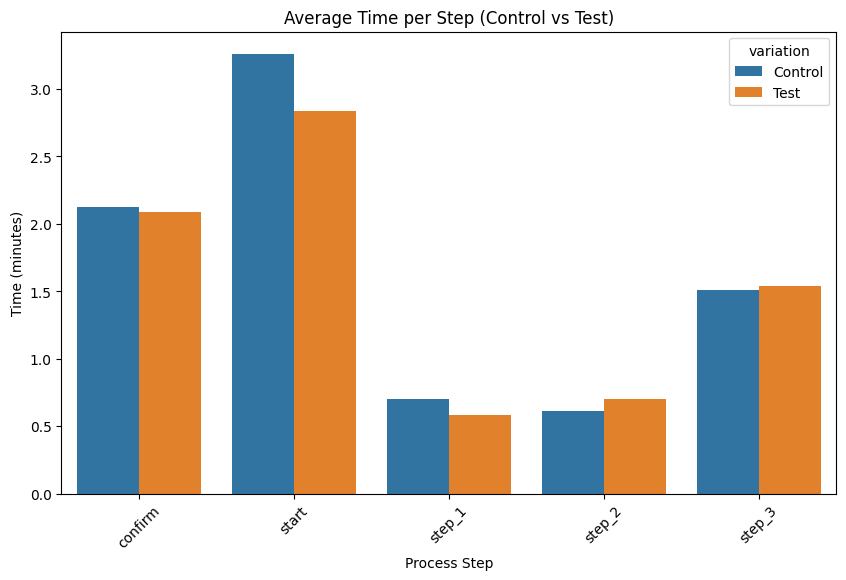

In [176]:
#Visualization of the KPI per step
plt.figure(figsize=(10,6))

sns.barplot(
    data=step_kpi,
    x='process_step',
    y='mean_time_min',
    hue='variation'
)

plt.title("Average Time per Step (Control vs Test)")
plt.ylabel("Time (minutes)")
plt.xlabel("Process Step")
plt.xticks(rotation=45)

plt.show()

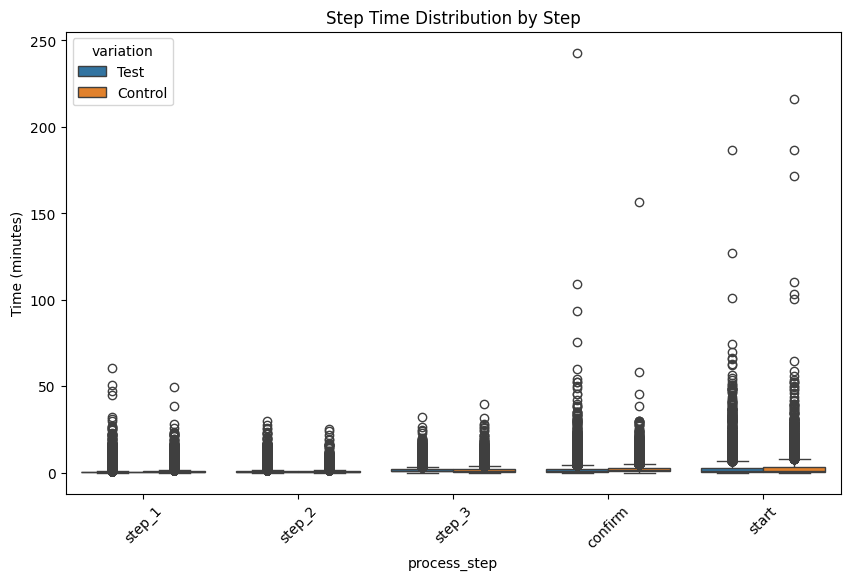

In [177]:
# Same thing, but with boxplots to see the distribution of times per step, not just the average
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_steps,
    x='process_step',
    y=df_steps['step_time_seconds'] / 60,
    hue='variation'
)

plt.title("Step Time Distribution by Step")
plt.ylabel("Time (minutes)")
plt.xticks(rotation=45)

plt.show()

### Out of users who reached a step, how many continued to the next one?
Combining time per step + drop-off rates gives us a full funnel story: efficiency + effectiveness.

In [182]:
# Ensure date_time is datetime
df_visit_window['date_time'] = pd.to_datetime(df_visit_window['date_time'])

# Merge experiment group into visit window data
df_visit_window = df_visit_window.merge(
    df_experiment[['client_id', 'variation']],
    on='client_id',
    how='left'
)

In [180]:
# Define funnel order
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

funnel = (
    df_visit_window.groupby(['visit_id', 'variation', 'process_step'])
    .size()
    .unstack(fill_value=0)
)

In [183]:
# Convert counts to binary reached/not reached
funnel = (funnel > 0).astype(int)

# Make sure all expected steps exist as columns
for step in step_order:
    if step not in funnel.columns:
        funnel[step] = 0

# Reorder columns
funnel = funnel[step_order]

# Count how many visits reached each step, by variation
step_counts = funnel.groupby('variation')[step_order].sum()

In [184]:
# Calculate conversion and drop-off rates between consecutive steps
dropoff_summary = step_counts.copy()

for i in range(len(step_order) - 1):
    current_step = step_order[i]
    next_step = step_order[i + 1]
    
    dropoff_summary[f'{current_step}_to_{next_step}_conversion'] = (
        step_counts[next_step] / step_counts[current_step]
    )
    
    dropoff_summary[f'{current_step}_to_{next_step}_dropoff'] = (
        1 - dropoff_summary[f'{current_step}_to_{next_step}_conversion']
    )

# Display results
print("Step counts:")
display(step_counts)

print("\nDrop-off summary:")
display(dropoff_summary)

Step counts:


process_step,start,step_1,step_2,step_3,confirm
variation,,,,,
Control,14893,14844,14820,14858,14889
Test,17890,17882,17862,17870,17894



Drop-off summary:


process_step,start,step_1,step_2,step_3,confirm,start_to_step_1_conversion,start_to_step_1_dropoff,step_1_to_step_2_conversion,step_1_to_step_2_dropoff,step_2_to_step_3_conversion,step_2_to_step_3_dropoff,step_3_to_confirm_conversion,step_3_to_confirm_dropoff
variation,,,,,,,,,,,,,
Control,14893,14844,14820,14858,14889,0.996710,0.003290,0.998383,0.001617,1.002564,-0.002564,1.002086,-0.002086
Test,17890,17882,17862,17870,17894,0.999553,0.000447,0.998882,0.001118,1.000448,-0.000448,1.001343,-0.001343


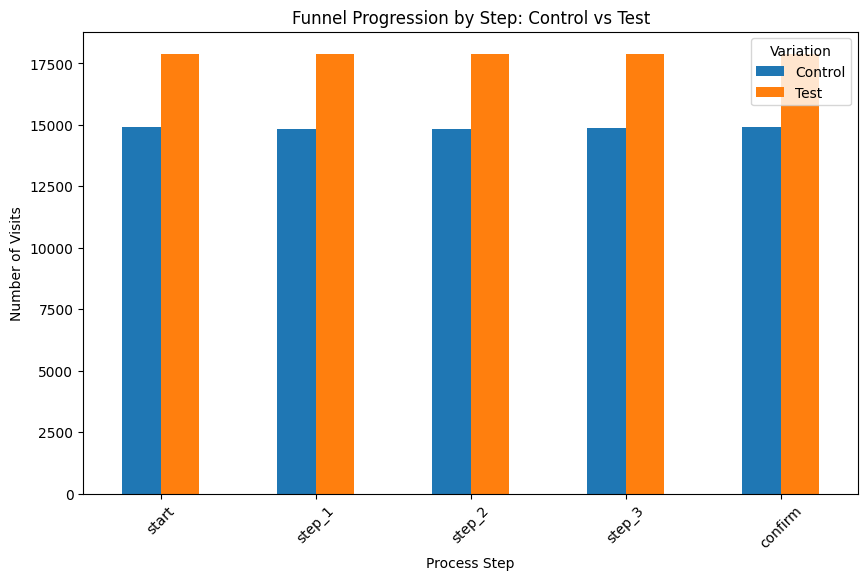

In [188]:
# Visualization: funnel counts by step
step_counts.T.plot(kind='bar', figsize=(10, 6))
plt.title('Funnel Progression by Step: Control vs Test')
plt.xlabel('Process Step')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.legend(title='Variation')
plt.show()

Conversion rate (CVR) is the percentage of users who complete a desired action

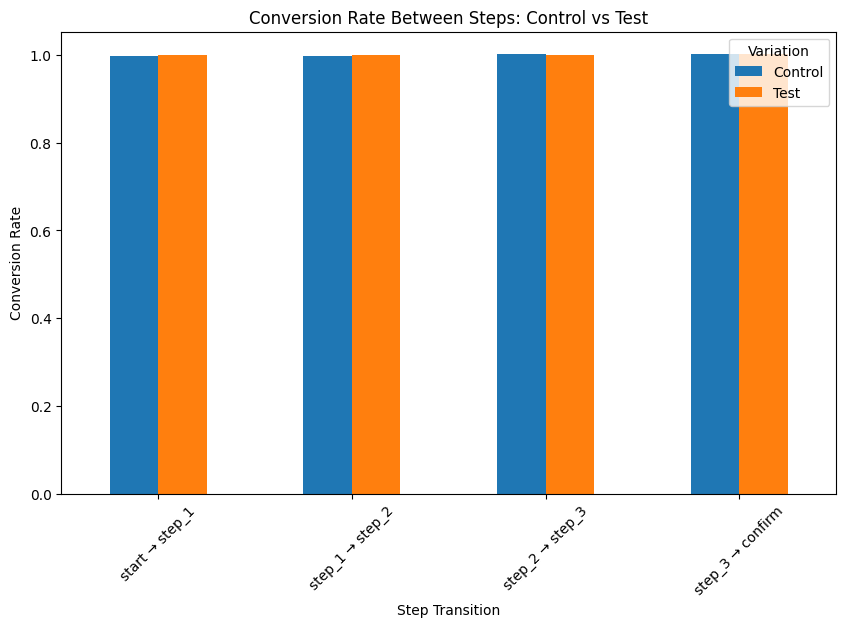

In [189]:
# Visualization: conversion rates between steps
conversion_cols = [col for col in dropoff_summary.columns if '_conversion' in col]

conversion_rates = dropoff_summary[conversion_cols].T
conversion_rates.index = [
    col.replace('_conversion', '').replace('_to_', ' → ')
    for col in conversion_rates.index
]

conversion_rates.plot(kind='bar', figsize=(10, 6))
plt.title('Conversion Rate Between Steps: Control vs Test')
plt.xlabel('Step Transition')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.legend(title='Variation')
plt.show()

Drop-off rate tracks the percentage of users who abandon a process or action before completion

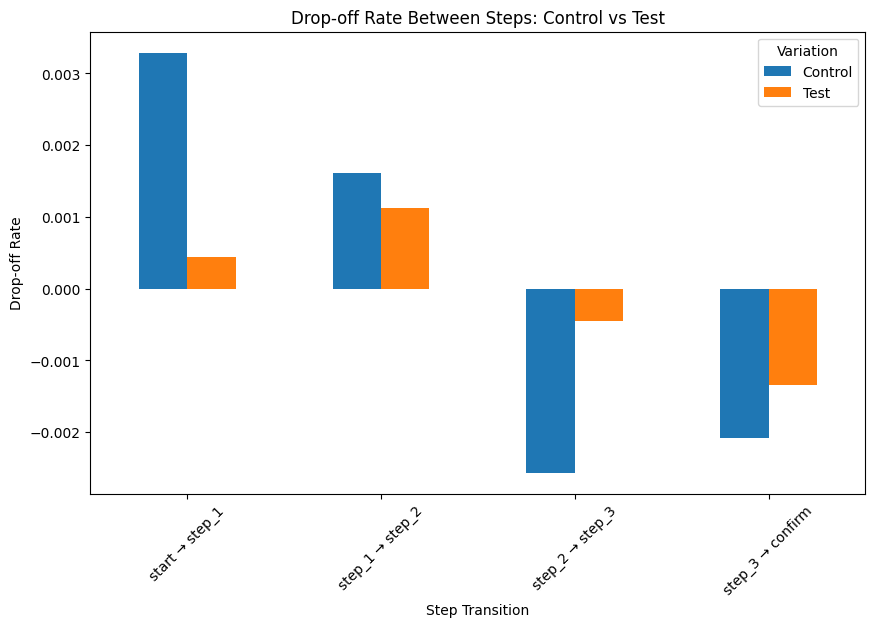

In [190]:
# Visualization: drop-off rates between steps
dropoff_cols = [col for col in dropoff_summary.columns if '_dropoff' in col]

dropoff_rates = dropoff_summary[dropoff_cols].T
dropoff_rates.index = [
    col.replace('_dropoff', '').replace('_to_', ' → ')
    for col in dropoff_rates.index
]

dropoff_rates.plot(kind='bar', figsize=(10, 6))
plt.title('Drop-off Rate Between Steps: Control vs Test')
plt.xlabel('Step Transition')
plt.ylabel('Drop-off Rate')
plt.xticks(rotation=45)
plt.legend(title='Variation')
plt.show()

### **Slide-ready explainer:**
We transformed each visit into a binary funnel path indicating whether the user reached each step at least once. This allowed us to measure, for each group, how many visits progressed through the funnel and where users dropped off between consecutive stages.

### What this gives us:

- step_counts = how many visits reached each step
- dropoff_summary = conversion and drop-off between each pair of steps

### 3 charts:

- total funnel progression
- conversion rates
- drop-off rates

### Important notes

- This treats a step as “reached” if it appears at least once in a visit. That is usually the right logic for funnel analysis.
- Negative drop-ff rates mean more users appear in the next step than in the previous step...some users may go directly to a step or enter mid-process. The funnel is not linear because it allows backtracking, jumping and re-tries.

Negative drop-off values reflect non-linear user behavior, where users may skip or re-enter steps, highlighting the complexity of the navigation flow.